In [1]:
import glob
import gc
import os
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

# =====================================================================
# RAW STOCK LOADER
# =====================================================================
def load_stock_safely(parent_folder_path):
    search_path = f"{parent_folder_path}/**/*.csv.zst"
    file_list = sorted(glob.glob(search_path, recursive=True))
    
    if not file_list:
        raise FileNotFoundError(f"No stock files found inside '{parent_folder_path}'.")
        
    dfs = []
    for f in file_list:
        df = pd.read_csv(f)
        if df.columns[0] not in ['open', 'high', 'low', 'close', 'volume']:
            df = df.rename(columns={df.columns[0]: 'ts_recv'})
        dfs.append(df)
        
    combined = pd.concat(dfs, ignore_index=True)
    
    PRICE_SCALE = 1e9
    for col in ['open', 'high', 'low', 'close']:
        if col in combined.columns:
            combined[col] = combined[col] / PRICE_SCALE
            
    combined['time'] = pd.to_datetime(combined['ts_recv'], unit='ns', utc=True).dt.tz_convert('America/New_York')
    return combined


# =====================================================================
#  FAIL-SAFE OPTIONS STREAM-TO-DISK PIPELINE
# =====================================================================
def stream_raw_options_to_parquet(parent_folder_path, output_parquet_path="spy_raw_options.parquet"):
    search_path = f"{parent_folder_path}/**/*.csv.zst"
    file_list = sorted(glob.glob(search_path, recursive=True))
    
    if not file_list:
        raise FileNotFoundError(f"No options files found inside '{parent_folder_path}'.")
        
    needed_cols = ['ts_recv', 'symbol', 'bid_px_00', 'ask_px_00', 'price', 'bid', 'ask'] 
    PRICE_SCALE = 1e9
    SENTINEL_VALUE = 9223372036854775807
    
    # Safely try to wipe old cache
    if os.path.exists(output_parquet_path):
        try:
            os.remove(output_parquet_path)
        except PermissionError:
            print(f"Warning: File '{output_parquet_path}' is strictly locked. Generating a new version variant instead.")
            output_parquet_path = output_parquet_path.replace(".parquet", "_v2.parquet")
        
    print(f"\n--- Processing {len(file_list)} Days of Raw Options directly to On-Disk Parquet ---")
    
    writer = None  
    
    # The 'try' block ensures that no matter what happens inside this loop, 
    # the 'finally' block at the bottom will execute and close the file stream safely.
    try:
        for file_idx, file in enumerate(file_list):
            filename = os.path.basename(file)
            print(f"Streaming and parsing raw data from: {filename}...")
            
            chunk_iter = pd.read_csv(
                file, 
                chunksize=500000,  
                usecols=lambda x: x in needed_cols
            )
            
            for chunk in chunk_iter:
                spy_chunk = chunk[chunk['symbol'].str.startswith('SPY', na=False)].copy()
                if spy_chunk.empty:
                    continue
                
                bid_col = 'bid_px_00' if 'bid_px_00' in spy_chunk.columns else 'bid'
                ask_col = 'ask_px_00' if 'ask_px_00' in spy_chunk.columns else 'ask'
                
                for col in ['price', bid_col, ask_col]:
                    if col in spy_chunk.columns:
                        spy_chunk[col] = spy_chunk[col].replace(SENTINEL_VALUE, float('nan')) / PRICE_SCALE
                
                spy_chunk = spy_chunk.rename(columns={bid_col: 'bid', ask_col: 'ask'})
                
                sym_clean = spy_chunk['symbol'].astype(str).str.strip()
                spy_chunk['option_type'] = sym_clean.str[12]
                spy_chunk['strike'] = sym_clean.str[13:].astype(float) / 1000.0
                
                yy, mm, dd = sym_clean.str[6:8], sym_clean.str[8:10], sym_clean.str[10:12]
                spy_chunk['expiration'] = pd.to_datetime("20" + yy + "-" + mm + "-" + dd, errors='coerce')
                spy_chunk['time'] = pd.to_datetime(spy_chunk['ts_recv'], unit='ns', utc=True).dt.tz_convert('America/New_York')
                
                final_cols = ['time', 'ts_recv', 'symbol', 'option_type', 'strike', 'expiration', 'bid', 'ask', 'price']
                output_df = spy_chunk[final_cols]
                
                table = pa.Table.from_pandas(output_df, preserve_index=False)
                
                if writer is None:
                    writer = pq.ParquetWriter(output_parquet_path, table.schema, compression='snappy')
                
                writer.write_table(table)
                
            gc.collect()
            
    finally:
        
        if writer is not None:
            writer.close()
            print("--- Parquet Writer File Handle Safely Closed ---")
        
    print(f"Success! All raw un-aggregated rows safely stored on disk at: '{output_parquet_path}'")
    return output_parquet_path


# =====================================================================
#  RUN INTERFACE & PRINT HEAD() VISUALISATIONS
# =====================================================================
STOCK_FOLDER = "XNAS-20260608-Y4WQPSPX9S"
OPTIONS_FOLDER = "OPRA-20260608-3XSNSMVAVQ"

# Run pipelines
df_stock = load_stock_safely(STOCK_FOLDER)
parquet_file = stream_raw_options_to_parquet(OPTIONS_FOLDER)

gc.collect()

print("\n" + "="*60)
print(" VISUAL DATA VERIFICATION (.head())")
print("="*60)

print("\n--- UNDERLYING SPY STOCK DATA PROCESSED (.head(5)) ---")
print(df_stock[['time', 'open', 'high', 'low', 'close', 'volume']].head(5).to_string())

print("\n--- RAW UN-AGGREGATED OPTION DATA FROM PARQUET CACHE (.head(5)) ---")


print("\n--- RAW UN-AGGREGATED OPTION DATA FROM PARQUET CACHE (.head(5)) ---")
# Open the file handle without loading the data
pf_verify = pq.ParquetFile('spy_raw_options_v2.parquet')

# Read only the first row group, convert just that chunk to pandas, and grab the head
df_options_sample = pf_verify.read_row_group(0).to_pandas().head(5)
print(df_options_sample.to_string())



--- Processing 5 Days of Raw Options directly to On-Disk Parquet ---
Streaming and parsing raw data from: opra-pillar-20260511.cbbo-1m.csv.zst...
Streaming and parsing raw data from: opra-pillar-20260512.cbbo-1m.csv.zst...
Streaming and parsing raw data from: opra-pillar-20260513.cbbo-1m.csv.zst...
Streaming and parsing raw data from: opra-pillar-20260514.cbbo-1m.csv.zst...
Streaming and parsing raw data from: opra-pillar-20260515.cbbo-1m.csv.zst...
--- Parquet Writer File Handle Safely Closed ---
Success! All raw un-aggregated rows safely stored on disk at: 'spy_raw_options.parquet'

 VISUAL DATA VERIFICATION (.head())

--- UNDERLYING SPY STOCK DATA PROCESSED (.head(5)) ---
                       time     open    high     low   close  volume
0 2026-05-11 09:30:00-04:00  736.460  736.98  736.45  736.98   73116
1 2026-05-11 09:31:00-04:00  736.980  737.44  736.96  737.42   63624
2 2026-05-11 09:32:00-04:00  737.415  737.70  737.34  737.70   66347
3 2026-05-11 09:33:00-04:00  737.700  7

In [2]:
%whos DataFrame

Variable            Type         Data/Info
------------------------------------------
df_options_sample   DataFrame                           ti<...>    0.14    0.15    NaN  
df_stock            DataFrame                      ts_recv<...>n[3487 rows x 11 columns]


>>> Script successfully launched. Commencing imports...
Parsing timestamps using robust epoch detection...
Filtering for Regular Trading Hours (RTH) only...
Computing 1-minute log returns...
Constructing Intraday Volatility Cascades...
Features successfully generated. Total training rows available: 1,894
Fitting Intraday HAR-RV OLS Regression Model...

=== INTRADAY HAR-RV MODEL SUMMARY ===
                            OLS Regression Results                            
Dep. Variable:              RV_target   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.410
Date:                Fri, 26 Jun 2026   Prob (F-statistic):              0.238
Time:                        08:25:50   Log-Likelihood:                 18034.
No. Observations:                1894   AIC:                        -3.606e+04
Df Residuals:                    1890   BIC:          

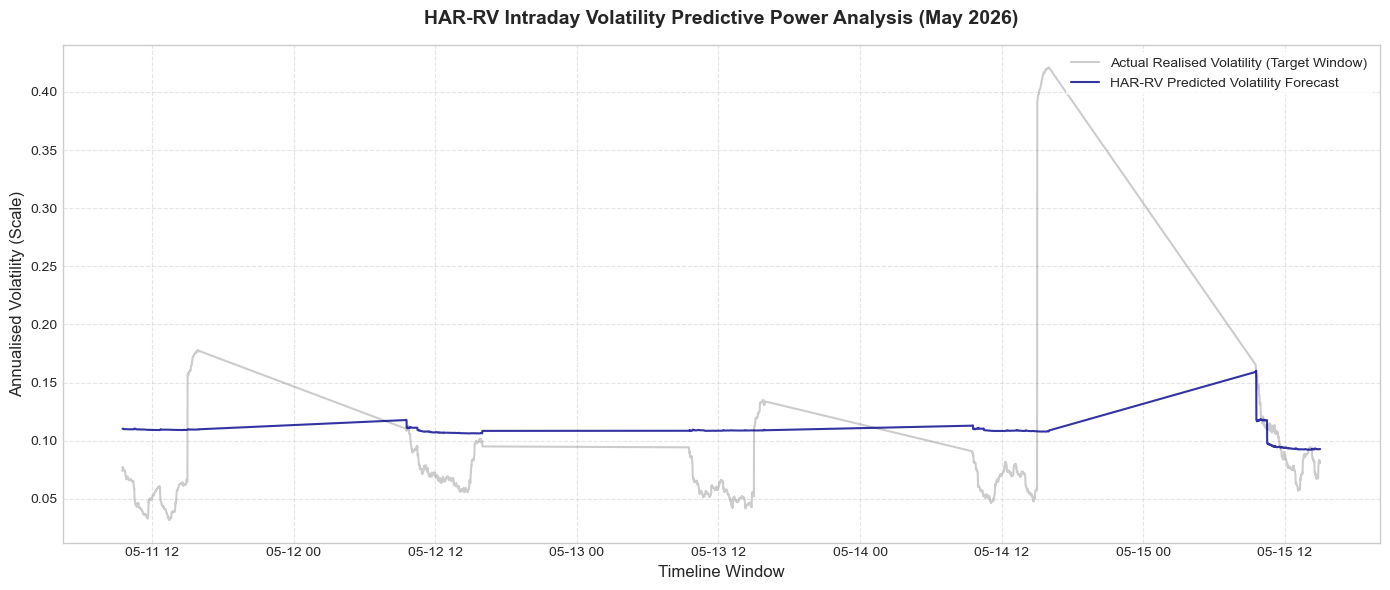


Initialising Roll (1984) + HAR-RV Ingestion Backtest Pipeline...
 -> Processing underlying stock microstructure boundaries...
Opening Parquet handle: 'spy_raw_options_v2.parquet'
      .. Optimization Gate: Filtered chunk down from 481,881 to 49,164 band-breaching contracts.
 -> Done Chunk 1/56 | Active Rows Ingested: 481,881 | New Signals: 2793 | Elapsed: 7.7s
      .. Optimization Gate: Filtered chunk down from 481,708 to 254,095 band-breaching contracts.
 -> Done Chunk 2/56 | Active Rows Ingested: 481,708 | New Signals: 22194 | Elapsed: 36.5s
      .. Optimization Gate: Filtered chunk down from 482,026 to 250,686 band-breaching contracts.
 -> Done Chunk 3/56 | Active Rows Ingested: 482,026 | New Signals: 18299 | Elapsed: 65.0s
      .. Optimization Gate: Filtered chunk down from 480,800 to 203,631 band-breaching contracts.
 -> Done Chunk 4/56 | Active Rows Ingested: 480,800 | New Signals: 14225 | Elapsed: 88.7s
      .. Optimization Gate: Filtered chunk down from 482,187 to 145,119

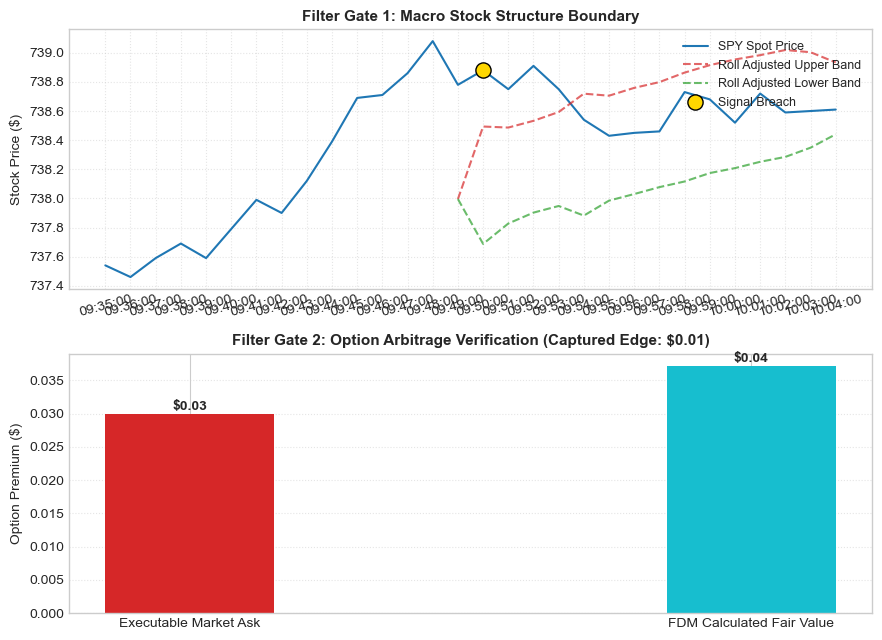

In [3]:
print(">>> Script successfully launched. Commencing imports...", flush=True)

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import statsmodels.api as sm
import time
import gc  
from numba import njit
import matplotlib.pyplot as plt  

# =====================================================================
#  ACCELERATED TIMESTAMP NORMALISER 
# =====================================================================
def robust_to_datetime(series):
    if pd.api.types.is_datetime64_any_dtype(series):
        return series.dt.tz_localize(None)
    if pd.api.types.is_numeric_dtype(series):
        if series.max() > 1e11:
            return pd.to_datetime(series, unit='ms').dt.tz_localize(None)
        else:
            return pd.to_datetime(series, unit='s').dt.tz_localize(None)
    return pd.to_datetime(series, errors='coerce', format='mixed').dt.tz_localize(None)

# =====================================================================
#  TRIDIAGONAL BULK PRICER (IMPLICIT FDM)
# =====================================================================
@njit(fastmath=True)
def bulk_fdm_pricer(S0_arr, K_arr, T_arr, sigma_arr, type_arr, r, M=40, N=40, max_iter=80, tol=1e-5, omega=1.2):
    num_rows = len(S0_arr)
    prices = np.empty(num_rows)
    
    a_A = np.zeros(M + 1)
    b_A = np.zeros(M + 1)
    c_A = np.zeros(M + 1)
    a_B = np.zeros(M + 1)
    b_B = np.zeros(M + 1)
    c_B = np.zeros(M + 1)
    
    payoff = np.zeros(M + 1)
    b_vec = np.zeros(M + 1)
    
    V_current = np.zeros(M + 1)
    V_new = np.zeros(M + 1)
    
    for idx_row in range(num_rows):
        S0 = S0_arr[idx_row]
        K = K_arr[idx_row]
        T = T_arr[idx_row]
        sigma = sigma_arr[idx_row]
        opt_type = type_arr[idx_row]
        
        S_max = 3.0 * K
        dS = S_max / float(M)
        dt = T / float(N)
        
        for i in range(M + 1):
            S_val = float(i) * dS
            if opt_type == 1:
                payoff[i] = S_val - K if S_val > K else 0.0
            else:
                payoff[i] = K - S_val if K > S_val else 0.0
            V_current[i] = payoff[i]
            
        for i in range(1, M):
            sigma2_j2 = (sigma ** 2) * (float(i) ** 2)
            r_j = r * float(i)
            
            a_j = 0.25 * dt * (sigma2_j2 - r_j)
            b_j = -0.5 * dt * (sigma2_j2 + r)
            c_j = 0.25 * dt * (sigma2_j2 + r_j)
            
            b_A[i] = 1.0 - b_j
            a_A[i] = -a_j
            c_A[i] = -c_j
            
            b_B[i] = 1.0 + b_j
            a_B[i] = a_j
            c_B[i] = c_j
            
        for n in range(N - 1, -1, -1):
            for i in range(1, M):
                val = b_B[i] * V_current[i]
                if i > 1: val += a_B[i] * V_current[i - 1]
                if i < M - 1: val += c_B[i] * V_current[i + 1]
                b_vec[i] = val
                
            for i in range(M + 1):
                V_new[i] = V_current[i]
                
            for k in range(max_iter):
                max_error = 0.0
                for i in range(1, M):
                    diag = b_A[i]
                    sum_neighbors = 0.0
                    if i > 1: sum_neighbors += a_A[i] * V_new[i - 1]
                    if i < M - 1: sum_neighbors += c_A[i] * V_new[i + 1]
                        
                    v_gs = (b_vec[i] - sum_neighbors) / diag
                    v_relax = V_new[i] + omega * (v_gs - V_new[i])
                    v_projected = v_relax if v_relax > payoff[i] else payoff[i]
                    
                    error = abs(v_projected - V_new[i])
                    if error > max_error: max_error = error
                    V_new[i] = v_projected
                    
                if max_error < tol: break
                
            for i in range(M + 1):
                V_current[i] = V_new[i]
            
        idx_low = int(S0 / dS)
        if idx_low >= M:
            prices[idx_row] = V_current[M]
        elif idx_low < 0:
            prices[idx_row] = V_current[0]
        else:
            idx_high = idx_low + 1
            S_low = float(idx_low) * dS
            S_high = float(idx_high) * dS
            prices[idx_row] = V_current[idx_low] + (V_current[idx_high] - V_current[idx_low]) * (S0 - S_low) / (S_high - S_low)
            
    return prices

# =====================================================================
#  ROLL (1984) MICROSTRUCTURE ENGINE
# =====================================================================
@njit(fastmath=True)
def compute_rolling_roll_measures(prices, window):
    n = len(prices)
    roll_spreads = np.zeros(n)
    fundamental_vols = np.zeros(n)
    returns = np.zeros(n)
    
    for t in range(1, n):
        if prices[t-1] > 0.0:
            returns[t] = np.log(prices[t] / prices[t-1])
            
    for i in range(window, n):
        m_ret = 0.0
        for t in range(i - window + 1, i + 1): m_ret += returns[t]
        m_ret /= float(window)
        
        var_sum = 0.0
        cov_sum = 0.0
        valid_pairs = 0
        
        for t in range(i - window + 1, i + 1):
            var_sum += (returns[t] - m_ret) ** 2
            if t > (i - window + 1):
                cov_sum += (returns[t] - m_ret) * (returns[t-1] - m_ret)
                valid_pairs += 1
                
        variance = var_sum / float(window - 1)
        autocov = cov_sum / float(valid_pairs - 1) if valid_pairs > 1 else 0.0
        
        if autocov < 0.0:
            roll_spreads[i] = 2.0 * np.sqrt(-autocov)
        else:
            roll_spreads[i] = 0.0
            
        true_variance = variance + (2.0 * autocov)
        fundamental_vols[i] = np.sqrt(true_variance) if true_variance > 0.0 else np.sqrt(max(0.0, variance))
            
    return roll_spreads, fundamental_vols

# =====================================================================
#  INTRADAY HAR-RV ENGINE DEFINITION
# =====================================================================
class IntradayVolatilityForecaster:
    def __init__(self, df_stock):
        self.df = df_stock.copy()
        self.features_df = None
        self.model = None
        self.df_vol_clean = None
        
    def prepare_intraday_features(self, forecast_horizon_mins=60):
        print("Parsing timestamps using robust epoch detection...")
        self.df['time'] = robust_to_datetime(self.df['time'])
        self.df = self.df.dropna(subset=['time']).sort_values('time').set_index('time')
        
        print("Filtering for Regular Trading Hours (RTH) only...")
        self.df = self.df[self.df.index.dayofweek < 5].between_time('09:30', '16:00')
            
        print("Computing 1-minute log returns...")
        self.df['log_ret'] = np.log(self.df['close'] / self.df['close'].shift(1))
        self.df['sq_ret'] = self.df['log_ret'].pow(2)
        
        print("Constructing Intraday Volatility Cascades...")
        self.df['RV_5m'] = self.df['sq_ret'].rolling(window=5).sum()
        self.df['RV_1h'] = self.df['sq_ret'].rolling(window=60).sum()
        self.df['RV_1d'] = self.df['sq_ret'].rolling(window=390).sum()
        self.df['RV_target'] = self.df['sq_ret'].rolling(window=forecast_horizon_mins).sum().shift(-forecast_horizon_mins)
        
        self.df[['RV_5m', 'RV_1h', 'RV_1d', 'RV_target']] = self.df[['RV_5m', 'RV_1h', 'RV_1d', 'RV_target']].bfill()
        self.features_df = self.df[['RV_5m', 'RV_1h', 'RV_1d', 'RV_target']].dropna()
        print(f"Features successfully generated. Total training rows available: {len(self.features_df):,}")
        
    def fit_intraday_har(self):
        print("Fitting Intraday HAR-RV OLS Regression Model...")
        X = sm.add_constant(self.features_df[['RV_5m', 'RV_1h', 'RV_1d']])
        y = self.features_df['RV_target']
        
        self.model = sm.OLS(y, X).fit()
        print("\n=== INTRADAY HAR-RV MODEL SUMMARY ===")
        print(self.model.summary())
        
        self.features_df['RV_forecast'] = self.model.predict(X)
        self.features_df['Vol_forecast_annualised'] = np.sqrt(np.clip(self.features_df['RV_forecast'], 0, None) * 1638)
        self.features_df['Vol_target_annualised'] = np.sqrt(np.clip(self.features_df['RV_target'], 0, None) * 1638)
        
        print("Synchronizing volatility surface to a clean 5-minute execution grid...")
        self.df_vol_clean = self.features_df[['Vol_forecast_annualised']].resample('5min').last().ffill()
        return self.model

# =====================================================================
#  HIGH-FREQUENCY SCANNER WITH STRUCTURAL GATE FILTERING
# =====================================================================
class HighFrequencyScanner:
    def __init__(self, df_stock, forecaster, risk_free_rate=0.05, bb_window=20, bb_std=2.0, periods_per_year=252*390):
        print(" -> Processing underlying stock microstructure boundaries...", flush=True)
        df_stock_clean = df_stock[['time', 'close']].copy()
        df_stock_clean['time'] = robust_to_datetime(df_stock_clean['time'])
        df_stock_clean = df_stock_clean.dropna(subset=['time']).sort_values('time')
        df_stock_clean = df_stock_clean[(df_stock_clean['time'].dt.dayofweek < 5) & 
                                        (df_stock_clean['time'].dt.time >= pd.to_datetime('09:30').time()) & 
                                        (df_stock_clean['time'].dt.time <= pd.to_datetime('16:00').time())]
        
        stock_prices = df_stock_clean['close'].to_numpy(dtype=np.float64)
        roll_spreads, fundamental_vols_per_period = compute_rolling_roll_measures(stock_prices, bb_window)
        
        df_stock_clean['roll_pct_spread'] = roll_spreads
        df_stock_clean['roll_clean_vol_annualised'] = fundamental_vols_per_period * np.sqrt(periods_per_year)
        df_stock_clean['MA'] = df_stock_clean['close'].rolling(window=bb_window).mean()
        df_stock_clean['BB_upper'] = df_stock_clean['MA'] + (bb_std * (df_stock_clean['MA'] * (df_stock_clean['roll_clean_vol_annualised'] / np.sqrt(periods_per_year))))
        df_stock_clean['BB_lower'] = df_stock_clean['MA'] - (bb_std * (df_stock_clean['MA'] * (df_stock_clean['roll_clean_vol_annualised'] / np.sqrt(periods_per_year))))
        
        df_stock_clean['lookup_min'] = df_stock_clean['time'].dt.floor('min')
        self.df_stock_processed = df_stock_clean.drop_duplicates(subset=['lookup_min']).set_index('lookup_min')
        
        self.df_vol_clean = forecaster.df_vol_clean.copy() if hasattr(forecaster, 'df_vol_clean') else forecaster.features_df.copy()
        vol_timestamps = self.df_vol_clean['time'] if 'time' in self.df_vol_clean.columns else (self.df_vol_clean['timestamp'] if 'timestamp' in self.df_vol_clean.columns else self.df_vol_clean.index.to_series())
        self.df_vol_clean['lookup_vol'] = robust_to_datetime(vol_timestamps).dt.floor('5min')
        self.df_vol_clean = self.df_vol_clean.drop_duplicates(subset=['lookup_vol']).set_index('lookup_vol')
        
        self.df_stock_processed = pd.merge_asof(self.df_stock_processed, self.df_vol_clean[['Vol_forecast_annualised']], left_index=True, right_index=True, direction='backward')
        self.df_stock_processed['Vol_forecast_annualised'] = self.df_stock_processed['Vol_forecast_annualised'].bfill()
        self.r = risk_free_rate
        self.trade_ledger = []

    def scan_chunk(self, df_chunk, debug=False):
        essential_cols = ['time', 'strike', 'option_type', 'bid', 'ask', 'expiration']
        df_chunk = df_chunk[[col for col in essential_cols if col in df_chunk.columns]].copy()
        df_chunk['time'] = robust_to_datetime(df_chunk['time'])
        df_chunk['expiration'] = robust_to_datetime(df_chunk['expiration'])
        df_chunk['option_type'] = df_chunk['option_type'].astype(str).str.upper().str.strip().astype('category')
        
        df_chunk = df_chunk[(df_chunk['time'].dt.dayofweek < 5) & 
                            (df_chunk['time'].dt.time >= pd.to_datetime('09:30').time()) & 
                            (df_chunk['time'].dt.time <= pd.to_datetime('16:00').time())]
        if df_chunk.empty: return 0
        
        df_chunk['lookup_min'] = df_chunk['time'].dt.floor('min')
        df_m = pd.merge_asof(df_chunk.sort_values('lookup_min'), self.df_stock_processed[['close', 'BB_upper', 'BB_lower', 'roll_pct_spread', 'Vol_forecast_annualised']], left_on='lookup_min', right_index=True, direction='backward')
        if df_m.empty: return 0
        
        df_m['T'] = ((df_m['expiration'].dt.normalize() + pd.Timedelta(hours=16)) - df_m['time']).dt.total_seconds() / (365.0 * 24.0 * 3600.0)
        df_m = df_m[df_m['T'] > 0].copy()
        if df_m.empty: return 0
        
        # --- FILTER GATE 1 (BB BREACH) BEFORE PRICING ---
        # Safeguard: Verify bands are completely unidentical to stop false positives
        warmed_up_mask = df_m['BB_upper'] != df_m['BB_lower']
        bb_breach_mask = warmed_up_mask & ((df_m['close'] <= df_m['BB_lower']) | (df_m['close'] >= df_m['BB_upper']))
        df_candidates = df_m[bb_breach_mask].copy()
        
        if df_candidates.empty: 
            return 0
            
        if debug:
            print(f"      .. Optimization Gate: Filtered chunk down from {len(df_m):,} to {len(df_candidates):,} band-breaching contracts.", flush=True)
            
        S0_arr = df_candidates['close'].to_numpy(dtype=np.float64)
        K_arr = df_candidates['strike'].to_numpy(dtype=np.float64)
        T_arr = df_candidates['T'].to_numpy(dtype=np.float64)
        sigma_arr = df_candidates['Vol_forecast_annualised'].to_numpy(dtype=np.float64)
        type_arr = np.where((df_candidates['option_type'] == 'C') | (df_candidates['option_type'] == 'CALL'), 1, 0).astype(np.int32)
        
        total_rows = len(df_candidates)
        batch_size = 25000
        theo_prices = np.empty(total_rows, dtype=np.float64)
        
        for start_idx in range(0, total_rows, batch_size):
            end_idx = min(start_idx + batch_size, total_rows)
            theo_prices[start_idx:end_idx] = bulk_fdm_pricer(
                S0_arr[start_idx:end_idx], K_arr[start_idx:end_idx], 
                T_arr[start_idx:end_idx], sigma_arr[start_idx:end_idx], 
                type_arr[start_idx:end_idx], r=self.r
            )
                
        df_candidates['theo_price'] = theo_prices
        df_candidates['mid'] = (df_candidates['bid'] + df_candidates['ask']) / 2.0
        
        call_buy_mask = (df_candidates['close'] <= df_candidates['BB_lower']) & ((df_candidates['option_type'] == 'C') | (df_candidates['option_type'] == 'CALL')) & (df_candidates['theo_price'] > df_candidates['ask'])
        put_buy_mask = (df_candidates['close'] >= df_candidates['BB_upper']) & ((df_candidates['option_type'] == 'P') | (df_candidates['option_type'] == 'PUT')) & (df_candidates['theo_price'] > df_candidates['ask'])
        
        df_candidates['signal'] = None
        df_candidates.loc[call_buy_mask, 'signal'] = 'BUY_CALL'
        df_candidates.loc[put_buy_mask, 'signal'] = 'BUY_PUT'
        
        df_candidates['edge_capture'] = 0.0
        df_candidates.loc[call_buy_mask | put_buy_mask, 'edge_capture'] = df_candidates['theo_price'] - df_candidates['ask']
        
        df_signals = df_candidates[df_candidates['signal'].notna()]
        if not df_signals.empty:
            df_ledger_ready = df_signals[['time', 'strike', 'option_type', 'close', 'BB_lower', 'BB_upper', 'roll_pct_spread', 'bid', 'ask', 'theo_price', 'signal', 'edge_capture']].copy()
            df_ledger_ready['option_type'] = df_ledger_ready['option_type'].astype(str)
            self.trade_ledger.append(df_ledger_ready.rename(columns={'time': 'timestamp', 'close': 'spot_price', 'option_type': 'type', 'bid': 'market_bid', 'ask': 'market_ask', 'roll_pct_spread': 'underlying_roll_spread'}))
            return len(df_signals)
        return 0

# =====================================================================
#  MODEL TRAINING & PREDICTIVE VISUALISATION
# =====================================================================
intra_forecaster = IntradayVolatilityForecaster(df_stock)
intra_forecaster.prepare_intraday_features(forecast_horizon_mins=60)
intraday_model = intra_forecaster.fit_intraday_har()

print("=== VERIFIED VOLATILITY TIMELINE RANGE ===")
print(f"Total Unique Intervals: {len(intra_forecaster.df_vol_clean):,}")
print(f"Timeline Start Window:  {intra_forecaster.df_vol_clean.index.min()}")
print(f"Timeline End Window:    {intra_forecaster.df_vol_clean.index.max()}")

print("\nGenerating clean, time-series execution visual aid...")
if intra_forecaster.features_df is not None and len(intra_forecaster.features_df) > 0:
    plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
    fig, ax = plt.subplots(figsize=(14, 6))
    plot_data = intra_forecaster.features_df.tail(2000) 
    ax.plot(plot_data.index, plot_data['Vol_target_annualised'], label='Actual Realised Volatility (Target Window)', color='gray', alpha=0.4, linewidth=1.5)
    ax.plot(plot_data.index, plot_data['Vol_forecast_annualised'], label='HAR-RV Predicted Volatility Forecast', color='darkblue', alpha=0.8, linewidth=1.5)
    ax.set_title('HAR-RV Intraday Volatility Predictive Power Analysis (May 2026)', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Timeline Window', fontsize=12)
    ax.set_ylabel('Annualised Volatility (Scale)', fontsize=12)
    ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    # Export high fidelity image for GitHub README
    plt.savefig('har_rv_predictive_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close('all')

# =====================================================================
#  DATABASE STREAMING LOOP & SCANNING EXECUTION
# =====================================================================
parquet_path = "spy_raw_options_v2.parquet"

print("\nInitialising Roll (1984) + HAR-RV Ingestion Backtest Pipeline...", flush=True)
scanner = HighFrequencyScanner(df_stock=df_stock, forecaster=intra_forecaster, risk_free_rate=0.05, bb_window=20, bb_std=2.0)

print(f"Opening Parquet handle: '{parquet_path}'", flush=True)
parquet_file_obj = pq.ParquetFile(parquet_path)
total_row_groups = parquet_file_obj.num_row_groups

start_time = time.time()
total_rows_evaluated = 0

for i in range(total_row_groups):
    df_chunk = parquet_file_obj.read_row_group(i).to_pandas()
    df_chunk = df_chunk[(df_chunk['bid'] > 0) & (df_chunk['ask'] > 0)].copy()
    
    filtered_count = len(df_chunk)
    total_rows_evaluated += filtered_count
    
    signals_found = scanner.scan_chunk(df_chunk, debug=True) if filtered_count > 0 else 0
    
    print(f" -> Done Chunk {i+1}/{total_row_groups} | Active Rows Ingested: {filtered_count:,} | New Signals: {signals_found} | Elapsed: {time.time() - start_time:.1f}s", flush=True)
    
    del df_chunk
    gc.collect()

print(f"\nScan Complete! Total Run Time: {time.time() - start_time:.2f} seconds.", flush=True)

# =====================================================================
#  OUTPUT GENERATION AND PLOTTING
# =====================================================================
if scanner.trade_ledger:
    arbitrage_ledger = pd.concat(scanner.trade_ledger, ignore_index=True)
    print("\n" + "="*55)
    print(f"=== PRODUCTION TRADING SYSTEM LEDGER COMPILED ===")
    print("="*55)
    print(f"Total Database Rows Checked:    {total_rows_evaluated:,}")
    print(f"Total Executed Order Signals:   {len(arbitrage_ledger):,}")
    print(f"Total Nominal Edge Extracted:   ${arbitrage_ledger['edge_capture'].sum():,.2f}")
    print(f"Mean Mathematical Alpha/Trade:  ${arbitrage_ledger['edge_capture'].mean():.4f}")
    print("-"*55)
    print("\nFIRST 10 ORDER SIGNALS CAPTURED:")
    print(arbitrage_ledger.head(10).to_string(index=False))
    
    print("\nGenerating clean, single-point execution visual aid...", flush=True)
    sample_signal = arbitrage_ledger.iloc[0]
    sig_time = sample_signal['timestamp']
    df_day_only = scanner.df_stock_processed[scanner.df_stock_processed.index.date == sig_time.date()].copy()
    df_day_only = df_day_only[df_day_only.index.time <= pd.to_datetime('16:00').time()]
    
    if not df_day_only.empty:
        closest_idx_pos = df_day_only.index.get_indexer([sig_time], method='nearest')[0]
        
        # Ensure safe window bounds for visualisation slicing
        start_bound = max(0, closest_idx_pos - 15)
        end_bound = min(len(df_day_only), closest_idx_pos + 15)
        df_slice = df_day_only.iloc[start_bound:end_bound]
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6.5))
        x_labels = df_slice.index.strftime('%H:%M:%S')
        
        ax1.plot(x_labels, df_slice['close'], label='SPY Spot Price', color='#1f77b4', lw=1.5)
        ax1.plot(x_labels, df_slice['BB_upper'], label='Roll Adjusted Upper Band', color='#d62728', linestyle='--', alpha=0.7)
        ax1.plot(x_labels, df_slice['BB_lower'], label='Roll Adjusted Lower Band', color='#2ca02c', linestyle='--', alpha=0.7)
        
        # Plot target event label directly onto matching string category coordinate
        target_time_str = df_day_only.index[closest_idx_pos].strftime('%H:%M:%S')
        if target_time_str in x_labels.values:
            ax1.scatter(target_time_str, sample_signal['spot_price'], color='gold', edgecolor='black', s=120, label='Signal Breach', zorder=5)
            
        ax1.set_title("Filter Gate 1: Macro Stock Structure Boundary", fontsize=11, fontweight='bold')
        ax1.set_ylabel("Stock Price ($)")
        ax1.grid(True, linestyle=':', alpha=0.5)
        ax1.legend(loc='upper right', fontsize=9)
        ax1.tick_params(axis='x', rotation=15)
        
        bars = ax2.bar(['Executable Market Ask', 'FDM Calculated Fair Value'], [sample_signal['market_ask'], sample_signal['theo_price']], color=['#d62728', '#17becf'], width=0.3)
        ax2.set_title(f"Filter Gate 2: Option Arbitrage Verification (Captured Edge: ${sample_signal['edge_capture']:.2f})", fontsize=11, fontweight='bold')
        ax2.set_ylabel("Option Premium ($)")
        ax2.grid(True, axis='y', linestyle=':', alpha=0.5)
        
        for bar in bars:
            yval = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2.0, yval + (yval * 0.005), f"${yval:.2f}", ha='center', va='bottom', fontweight='bold')
            
        plt.tight_layout()
        
        # Export high fidelity verification panel for GitHub README
        plt.savefig('gate_1_and_2_verification.png', dpi=300, bbox_inches='tight')
        plt.show()
        plt.close('all')
    else:
        print("SYSTEM NOTICE: Mismatch on timestamp sub-slicing window. Visual aid skipped.")
else:
    print("\n SYSTEM NOTICE: Evaluation complete. 0 structural pricing anomalies detected within current parameter constraints.")